In [1]:
!pip install timm -q

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [4]:
DATA_DIR  = Path("/kaggle/input/competitions/siim-isic-melanoma-classification")
CSV_PATH  = DATA_DIR / "train.csv"
IMAGE_DIR = DATA_DIR / "jpeg/train"

print("CSV exists:",          CSV_PATH.exists())
print("Image folder exists:", IMAGE_DIR.exists())
print("CUDA available:",      torch.cuda.is_available())

df = pd.read_csv(CSV_PATH)

print(df.head())
print(df["target"].value_counts())
print("Image folder exists:", IMAGE_DIR.exists())

CSV exists: True
Image folder exists: True
CUDA available: True
     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_2637011  IP_7279968    male        45.0                     head/neck   
1  ISIC_0015719  IP_3075186  female        45.0               upper extremity   
2  ISIC_0052212  IP_2842074  female        50.0               lower extremity   
3  ISIC_0068279  IP_6890425  female        45.0                     head/neck   
4  ISIC_0074268  IP_8723313  female        55.0               upper extremity   

  diagnosis benign_malignant  target  
0   unknown           benign       0  
1   unknown           benign       0  
2     nevus           benign       0  
3   unknown           benign       0  
4   unknown           benign       0  
target
0    32542
1      584
Name: count, dtype: int64
Image folder exists: True


In [5]:
sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

train_idx, val_idx = next(
    sgkf.split(df, df["target"], groups=df["patient_id"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

overlap = set(train_df["patient_id"]) & set(val_df["patient_id"])
print("Patient overlap:", len(overlap))

Train size: 21980
Validation size: 11146
Patient overlap: 0


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self.image_dir / f"{row['image_name']}.jpg"
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["target"], dtype=torch.float32)

        return image, label

In [8]:
train_set = MelanomaDataset(train_df, IMAGE_DIR, train_transform)
val_set = MelanomaDataset(val_df, IMAGE_DIR, val_transform)

train_loader = DataLoader(
    train_set,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_set,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 344
Validation batches: 175


In [9]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First labels:", labels[:10])

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
First labels: tensor([1., 0., 0., 0., 0., 0., 1., 0., 0., 0.])


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = timm.create_model("resnet50", pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

print(next(model.parameters()).device)

Device: cuda


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

cuda:0


In [11]:
num_pos = train_df["target"].sum()
num_neg = len(train_df) - num_pos

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [13]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(loader.dataset)
    auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, auc, np.array(all_labels), np.array(all_probs)

In [14]:
EPOCHS = 10

train_losses = []
val_losses = []
val_aucs = []

best_auc = 0.0
best_model_path = "/kaggle/working/resnet50_baseline.pth"

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auc, y_true, y_prob = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val AUC: {val_auc:.4f}",
        flush=True
    )

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), best_model_path)
        print("Saved best model", flush=True)

print("Best Val AUC:", best_auc)

Epoch 1/10 | Train Loss: 1.1701 | Val Loss: 1.0403 | Val AUC: 0.8182
Saved best model
Epoch 2/10 | Train Loss: 0.9141 | Val Loss: 0.9381 | Val AUC: 0.8304
Saved best model
Epoch 3/10 | Train Loss: 0.8198 | Val Loss: 0.8611 | Val AUC: 0.8675
Saved best model
Epoch 4/10 | Train Loss: 0.7895 | Val Loss: 0.8511 | Val AUC: 0.8723
Saved best model
Epoch 5/10 | Train Loss: 0.7065 | Val Loss: 0.8860 | Val AUC: 0.8665
Epoch 6/10 | Train Loss: 0.6581 | Val Loss: 0.8398 | Val AUC: 0.8774
Saved best model
Epoch 7/10 | Train Loss: 0.6272 | Val Loss: 0.9479 | Val AUC: 0.8706
Epoch 8/10 | Train Loss: 0.5829 | Val Loss: 0.8999 | Val AUC: 0.8774
Saved best model
Epoch 9/10 | Train Loss: 0.5688 | Val Loss: 1.0377 | Val AUC: 0.8574
Epoch 10/10 | Train Loss: 0.5362 | Val Loss: 1.0205 | Val AUC: 0.8582
Best Val AUC: 0.8773853672286785


In [15]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

val_loss, val_auc, y_true, y_prob = validate(model, val_loader, criterion, device)

y_pred = (y_prob >= 0.5).astype(int)

print("Final Validation Loss:", val_loss)
print("Final Validation AUC:", val_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Melanoma"]))

Final Validation Loss: 0.8999154734136642
Final Validation AUC: 0.8773853672286785

Confusion Matrix:
[[8545 2404]
 [  38  159]]

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.78      0.87     10949
    Melanoma       0.06      0.81      0.12       197

    accuracy                           0.78     11146
   macro avg       0.53      0.79      0.50     11146
weighted avg       0.98      0.78      0.86     11146



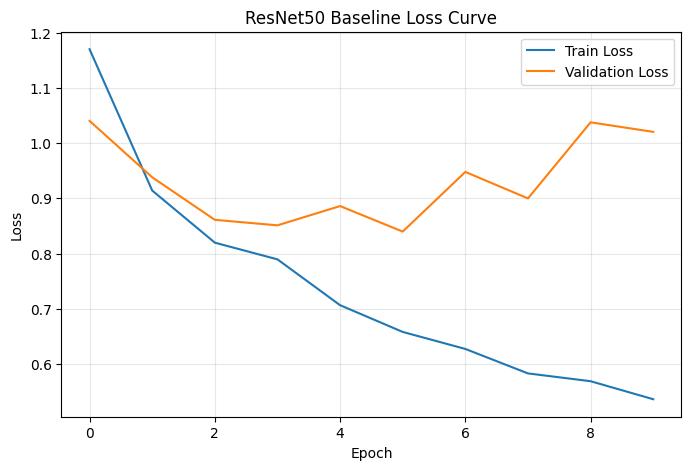

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Baseline Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

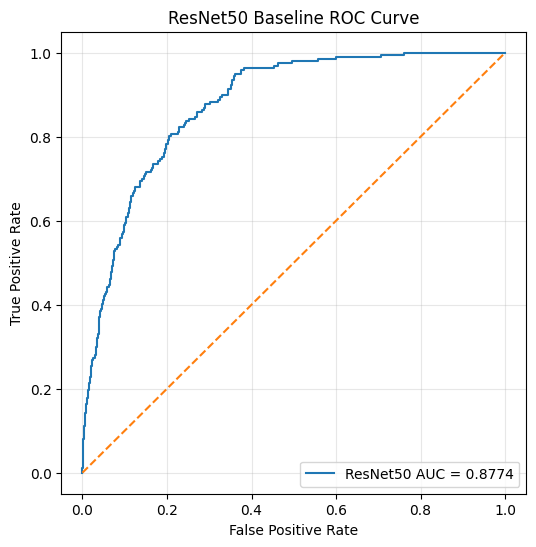

In [17]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ResNet50 AUC = {val_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 Baseline ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

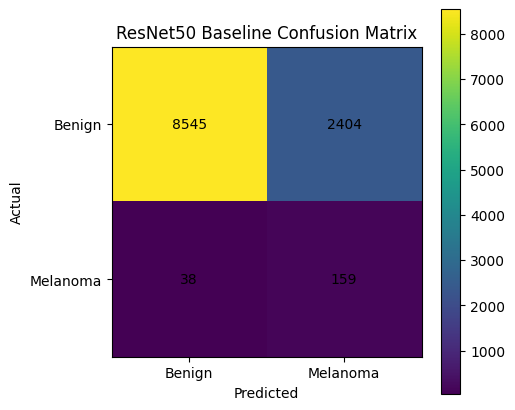

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("ResNet50 Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Benign", "Melanoma"])
plt.yticks([0, 1], ["Benign", "Melanoma"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [19]:
results_df = pd.DataFrame({
    "epoch": list(range(1, EPOCHS + 1)),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "val_auc": val_aucs
})

results_df.to_csv("/kaggle/working/resnet50_baseline_results.csv", index=False)
results_df

,epoch,train_loss,val_loss,val_auc
0,1,1.170145,1.040331,0.818208
1,2,0.914145,0.938149,0.830435
2,3,0.819757,0.861122,0.867517
3,4,0.789498,0.851141,0.872266
4,5,0.706490,0.886022,0.866482
5,6,0.658067,0.839819,0.877376
6,7,0.627239,0.947891,0.870633
7,8,0.582928,0.899915,0.877385
8,9,0.568785,1.037719,0.857439
9,10,0.536167,1.020476,0.858178
